# Spatial RFs of encoding and prediction model

This notebook displays all the spatial RFs of the encoding and of the prediction model (Supplementary Figure 3 & 4 & 5).

In [37]:
import os
import torch
import numpy as np
from retina import train, analysis
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")#Nicol

In [39]:
prediction_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")
prediction_model_no_reg = train.Trainer.load_model(f"{root}/results", "0_*_0.01_0.6_128_8")
encoding_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_0_8")

/home/nicolharper/miniconda3/envs/retina/lib/python3.8/site-packages/devtorch/query.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(mod

In [41]:
torch.manual_seed(0)
prediction_rf_query = analysis.RFQuery(root, prediction_model,t_len=200,samples=5000)

torch.manual_seed(0)
prediction_no_reg_rf_query = analysis.RFQuery(root, prediction_model_no_reg,t_len=200,samples=5000)

torch.manual_seed(0)
encoding_rf_query = analysis.RFQuery(root, encoding_model,t_len=200,samples=5000)

INFO:util:Processing batch 0 out of 100...
INFO:util:Processing batch 10 out of 100...
INFO:util:Processing batch 20 out of 100...
INFO:util:Processing batch 30 out of 100...
INFO:util:Processing batch 40 out of 100...
INFO:util:Processing batch 50 out of 100...
INFO:util:Processing batch 60 out of 100...
INFO:util:Processing batch 70 out of 100...
INFO:util:Processing batch 80 out of 100...
INFO:util:Processing batch 90 out of 100...
INFO:gaussian:CC criteria exclusion 193
INFO:gaussian:Location criteria exclusion 38
INFO:gaussian:Envelope criteria exclusion 12
INFO:util:Processing batch 0 out of 100...
INFO:util:Processing batch 10 out of 100...
INFO:util:Processing batch 20 out of 100...
INFO:util:Processing batch 30 out of 100...
INFO:util:Processing batch 40 out of 100...
INFO:util:Processing batch 50 out of 100...
INFO:util:Processing batch 60 out of 100...
INFO:util:Processing batch 70 out of 100...
INFO:util:Processing batch 80 out of 100...
INFO:util:Processing batch 90 out of

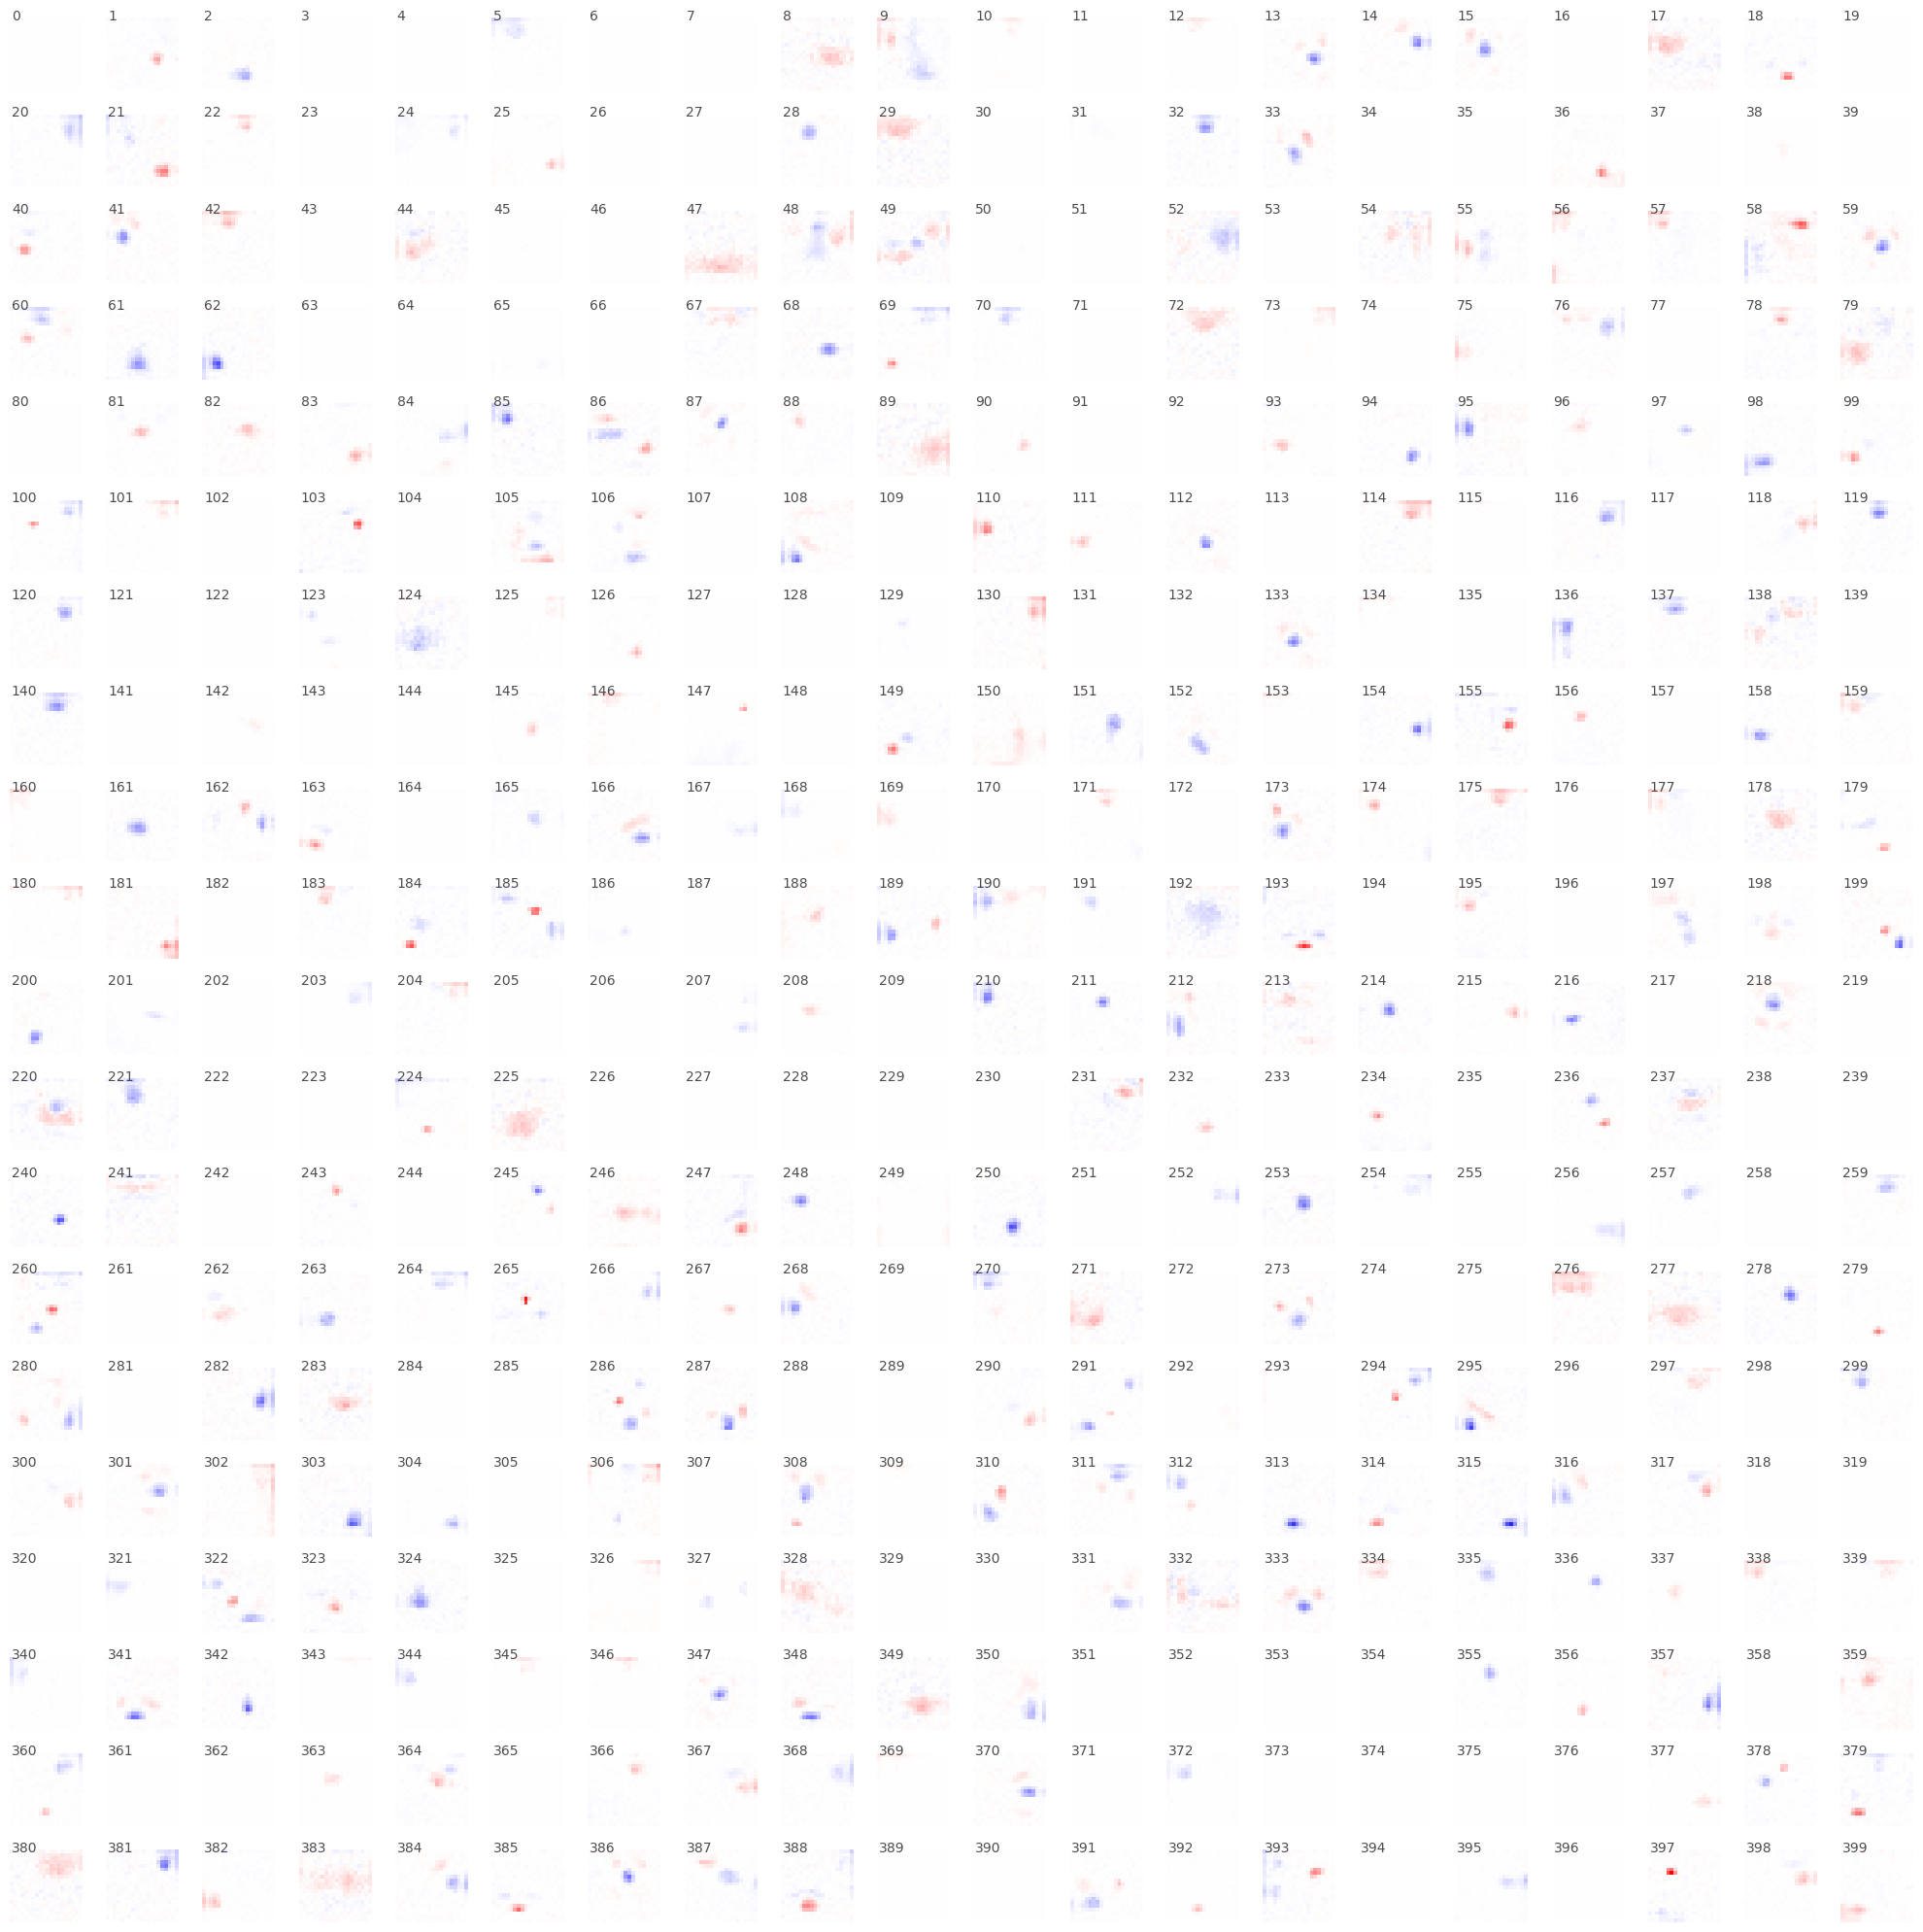

In [42]:
#Plot spatial RFs
analysis.plot_spatial_rfs(prediction_rf_query.mean_rfs, 20, 20, range_all=True)

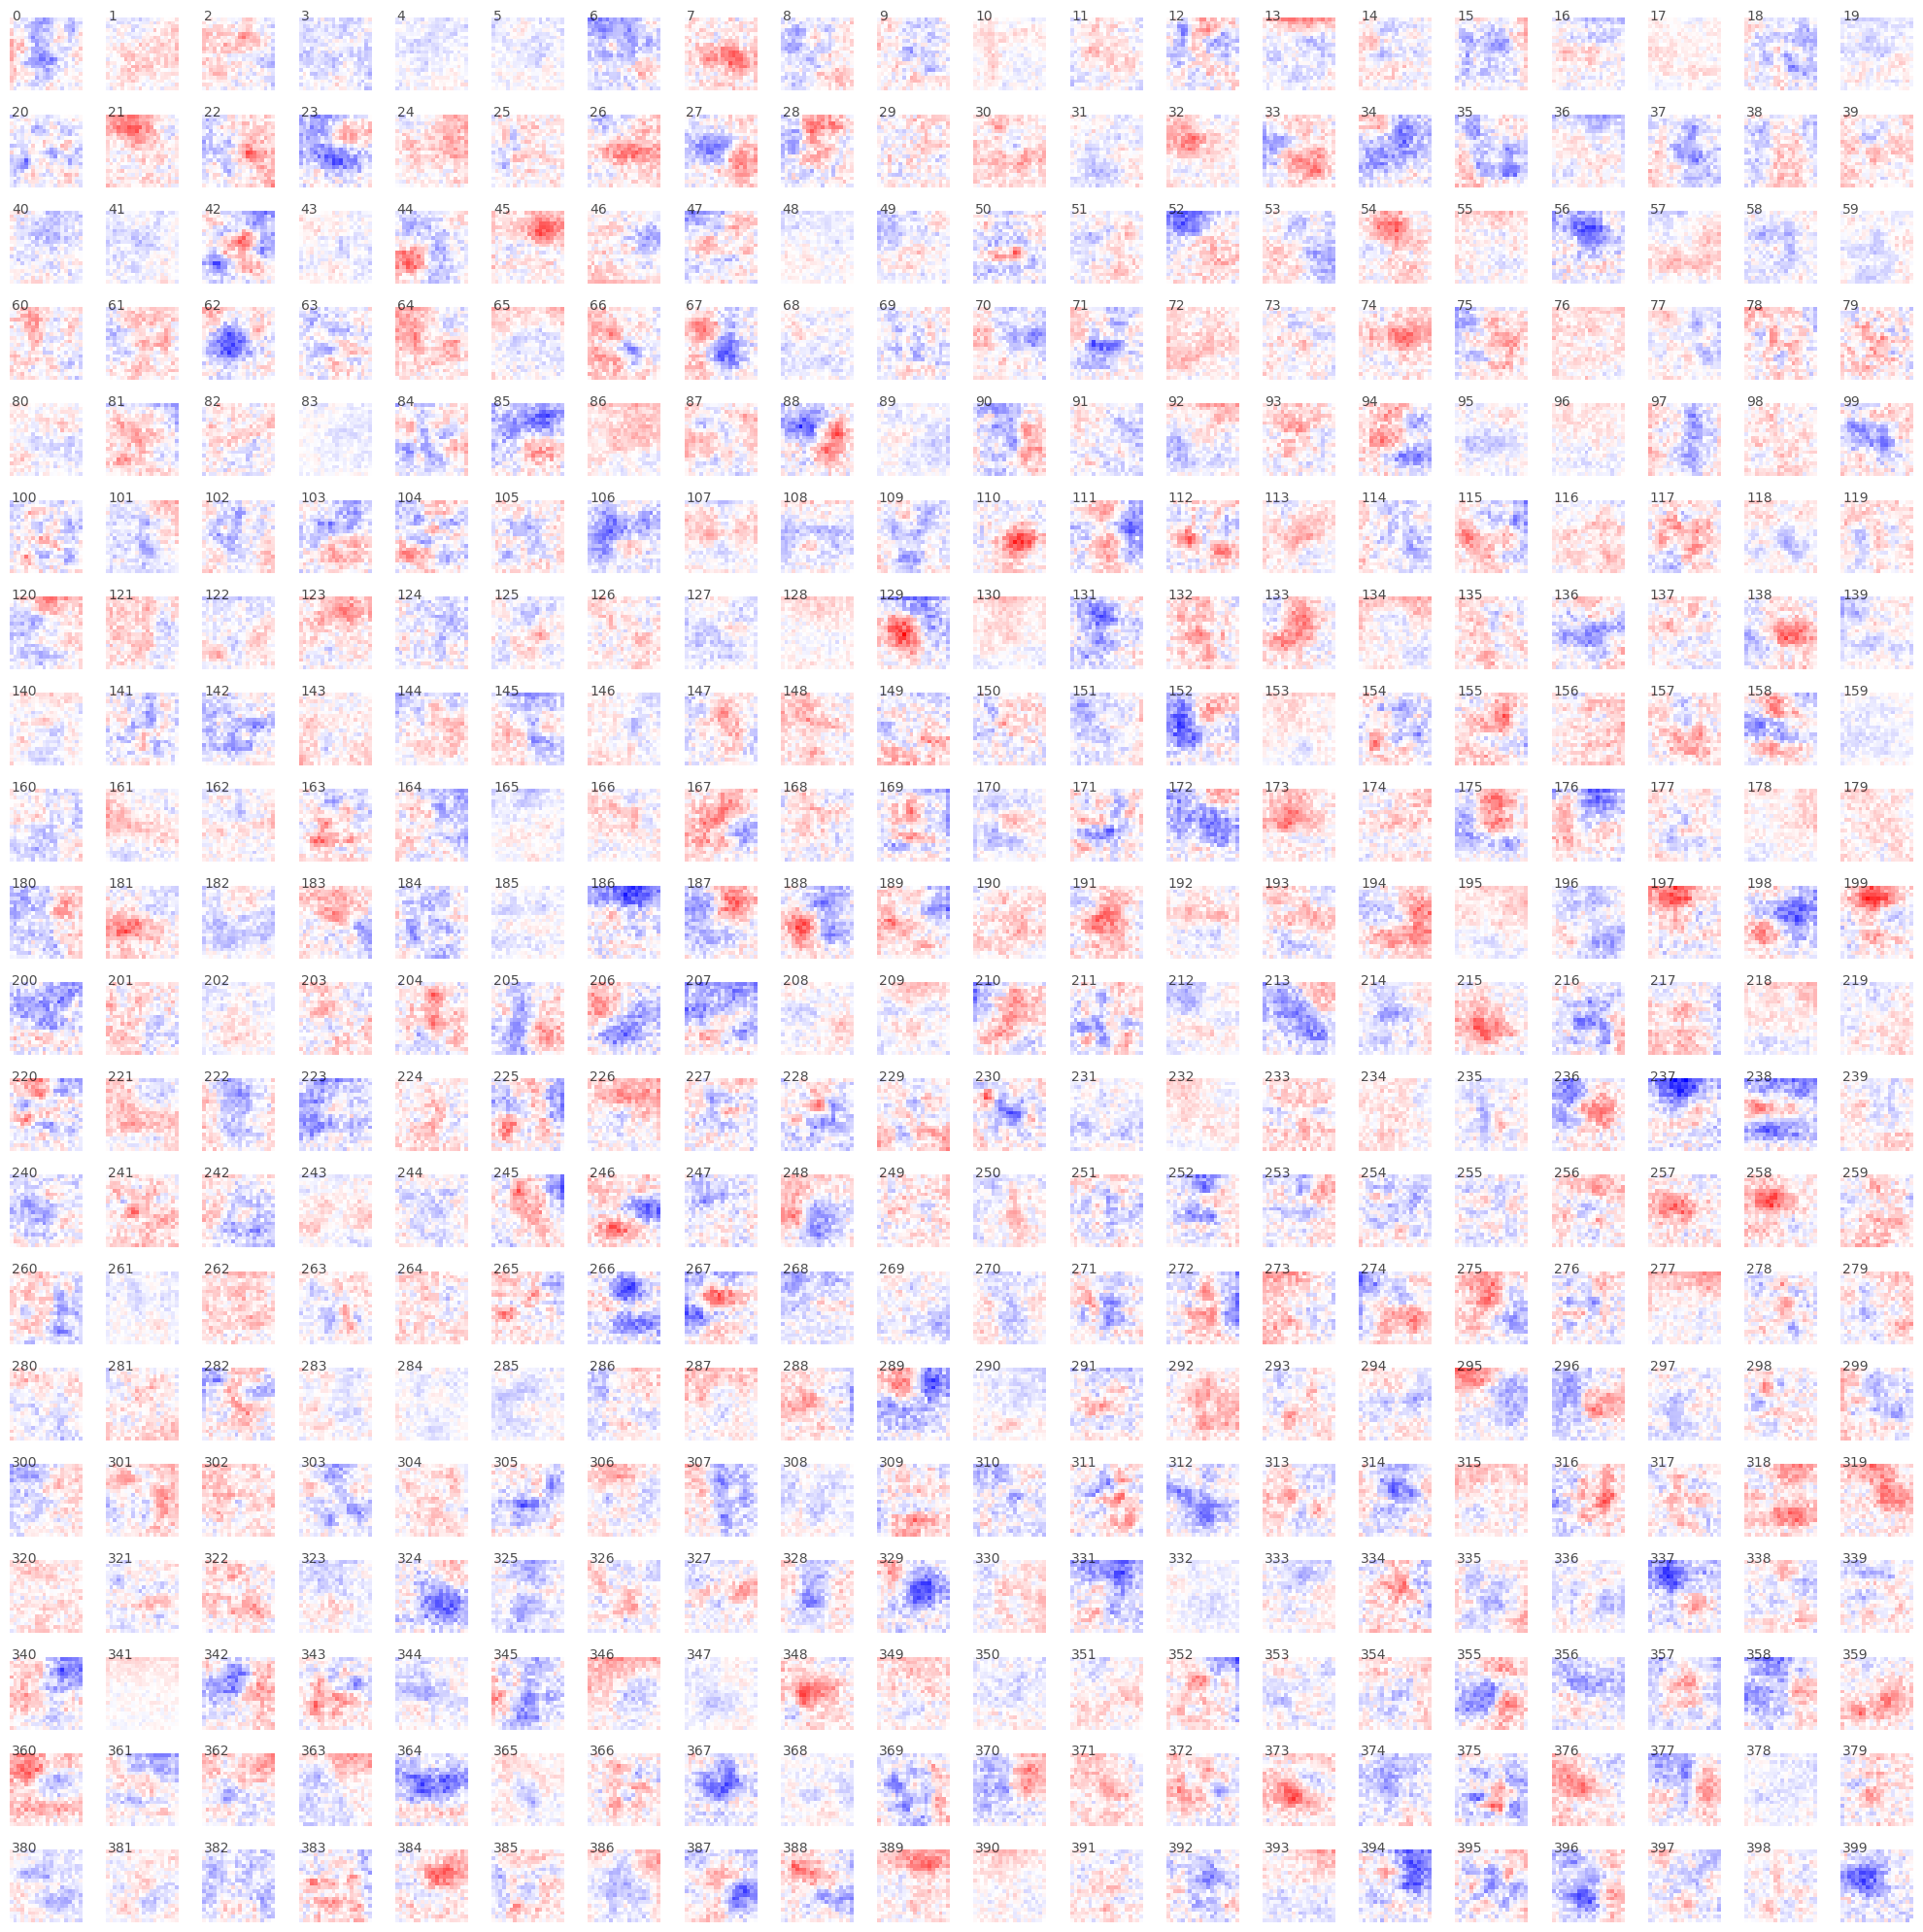

In [43]:
analysis.plot_spatial_rfs(prediction_no_reg_rf_query.rfs, 20, 20, range_all=True)

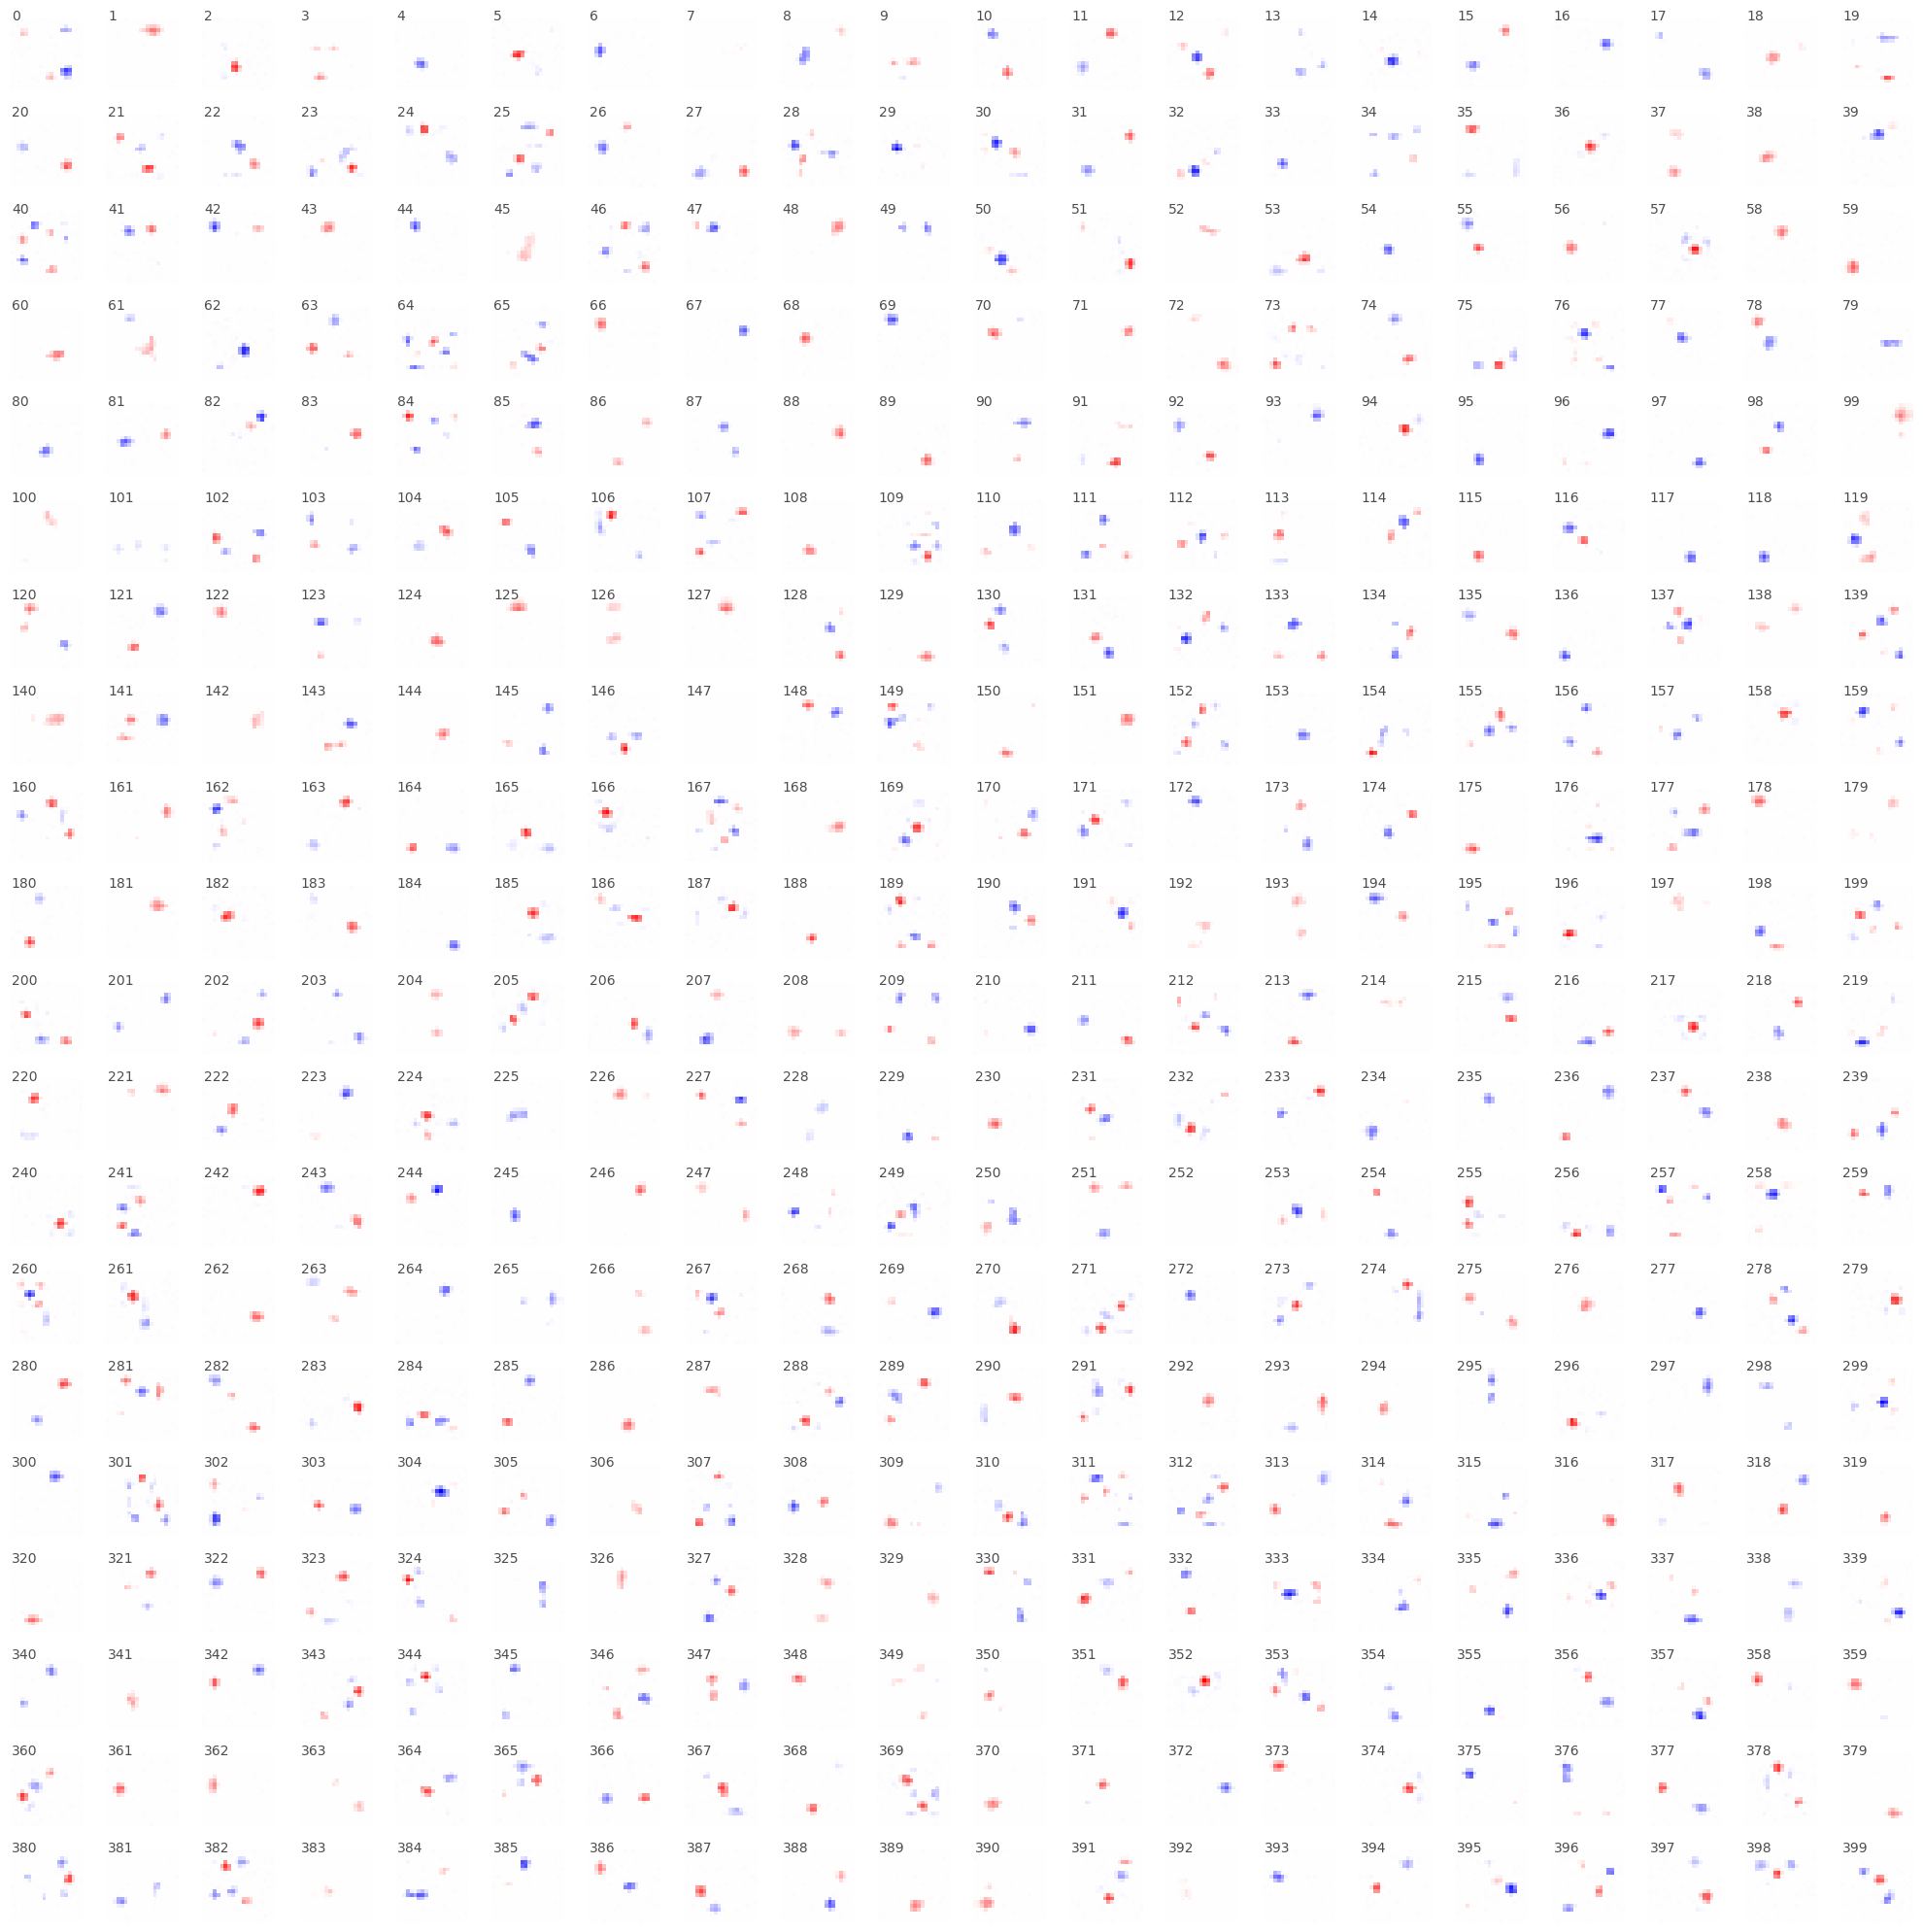

In [44]:
analysis.plot_spatial_rfs(encoding_rf_query.rfs, 20, 20, range_all=True)

In [31]:
#High resolution RFs
#takes a long time to run

torch.manual_seed(0)

#high_resolution_rf_query = prediction_rf_query
high_resolution_rf_query = analysis.RFQuery(root, prediction_model,t_len=200,samples=100000)#was 1000000 for figure in paper

INFO:util:Processing batch 0 out of 2000...
INFO:util:Processing batch 100 out of 2000...
INFO:util:Processing batch 200 out of 2000...
INFO:util:Processing batch 300 out of 2000...
INFO:util:Processing batch 400 out of 2000...
INFO:util:Processing batch 500 out of 2000...
INFO:util:Processing batch 600 out of 2000...
INFO:util:Processing batch 700 out of 2000...
INFO:util:Processing batch 800 out of 2000...
INFO:util:Processing batch 900 out of 2000...
INFO:util:Processing batch 1000 out of 2000...
INFO:util:Processing batch 1100 out of 2000...
INFO:util:Processing batch 1200 out of 2000...
INFO:util:Processing batch 1300 out of 2000...
INFO:util:Processing batch 1400 out of 2000...
INFO:util:Processing batch 1500 out of 2000...
INFO:util:Processing batch 1600 out of 2000...
INFO:util:Processing batch 1700 out of 2000...
INFO:util:Processing batch 1800 out of 2000...
INFO:util:Processing batch 1900 out of 2000...
INFO:gaussian:CC criteria exclusion 193
INFO:gaussian:Location criteria 

In [34]:
def plot_spatiotemporal_rf(strf, i, subspec, fig, localnorm=False, column=False):
    strf = strf.cpu().detach()
    if localnorm==False:
        maxv = strf.abs().max()
    
    for j in range(0, len(strf)):
        if localnorm==True:
            maxv = strf[j].abs().max()
        if column==True:
            ax = plt.Subplot(fig, subspec[len(strf)-j, i])
        else:
            ax = plt.Subplot(fig, subspec[i, j])
        fig.add_subplot(ax)
        im = ax.imshow(strf[j], cmap="seismic", vmin=-maxv, vmax=maxv)
        ax.axis("off")

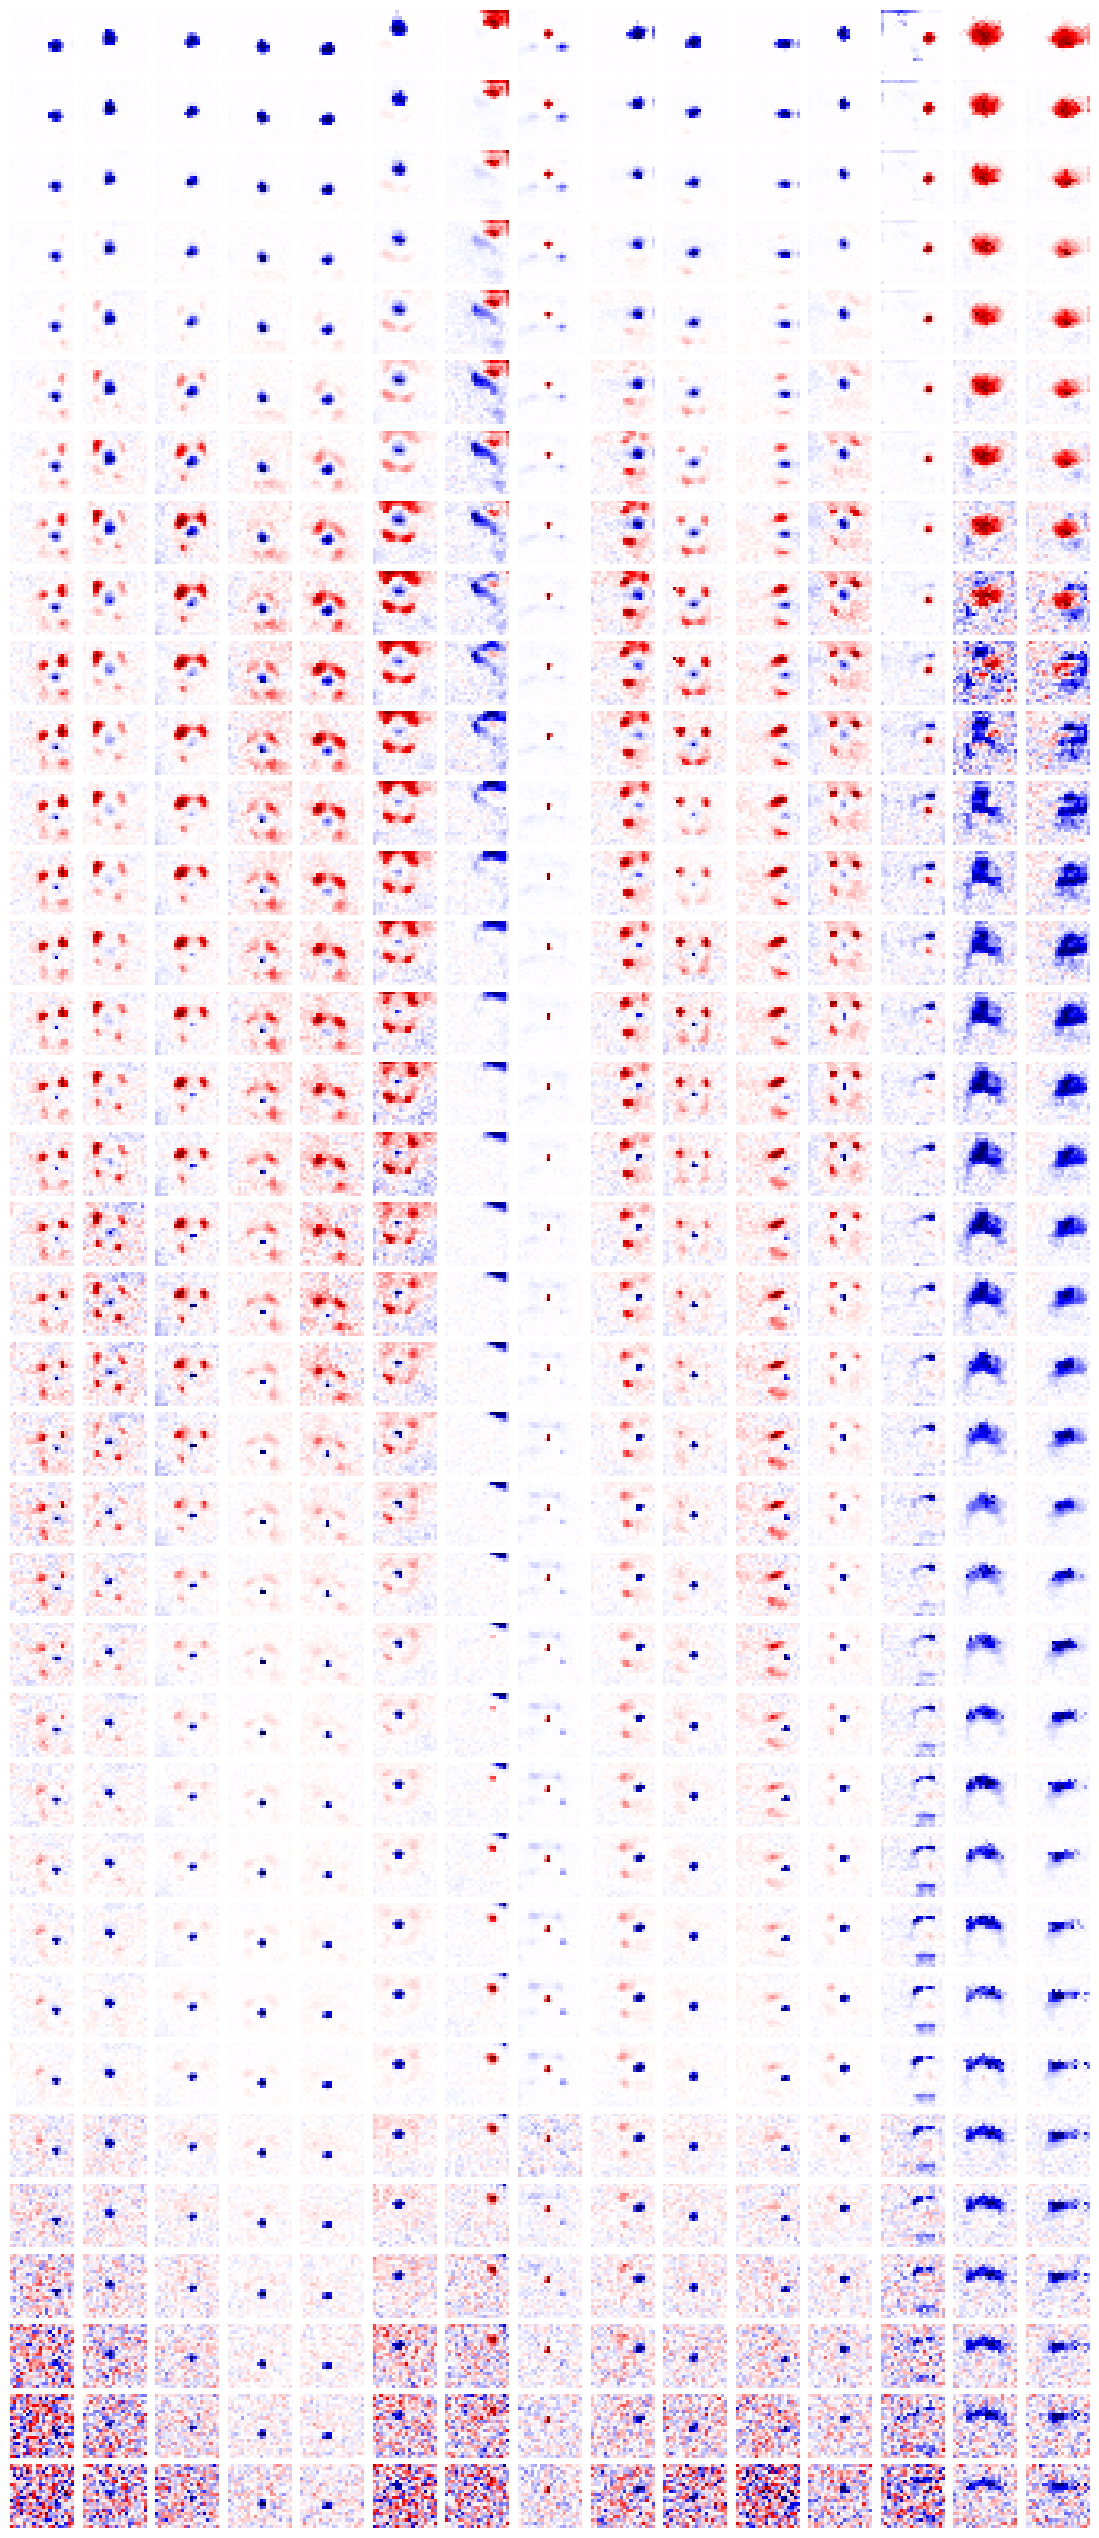

In [35]:
#Plot some spatiotemporal RFs with surrounds

import matplotlib.gridspec as gridspec
l = 30
fig = plt.figure(constrained_layout=True, figsize=(14, 100))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(50, 15, subplot_spec=spec[0], hspace=0.1, wspace=0.05)
bottom_spec = gridspec.GridSpecFromSubplotSpec(50, 15, subplot_spec=spec[1], hspace=0.1, wspace=0.05)

plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[13, :], 0, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[15, :], 1, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[59, :], 2, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[112, :], 3, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[133, :], 4, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[218, :], 5, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[231, :], 6, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[265, :], 7, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[301, :], 8, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[347, :], 9, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[370, :], 10, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[386, :], 11, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[155, :], 12, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[178, :], 13, top_spec, fig, localnorm=True, column=True)
plot_spatiotemporal_rf(high_resolution_rf_query.og_strfs[283, :], 14, top_spec, fig, localnorm=True, column=True)

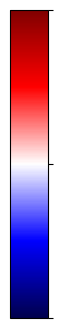

In [36]:
#Plot color bar

import matplotlib.pyplot as plt
import numpy as np

# Create vertical colorbar figure
fig, ax = plt.subplots(figsize=(1, 4))
fig.subplots_adjust(right=0.5)

# Define colormap and normalization
cmap = plt.get_cmap('seismic')
norm = plt.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

# Create colorbar
cb = plt.colorbar(sm, cax=ax, orientation='vertical')

# Set custom ticks and remove their labels
cb.set_ticks([-1, 0, 1])
cb.ax.set_yticklabels(['', '', ''])  # Keep tick marks, hide labels

plt.show()